In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Road.csv")

In [4]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [5]:
df.shape

(12316, 32)

In [6]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [7]:
df.info()#checking detailed data set info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [8]:
df.describe()#checking numerical summary

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [9]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

DATA CLEANING


In [10]:
df_clean = df.copy() 
#Creates a copy of the original dataset , We’ll clean df_clean instead of changing df directly

In [11]:
df_clean.columns = df_clean.columns.str.strip().str.lower()
df_clean.columns

Index(['time', 'day_of_week', 'age_band_of_driver', 'sex_of_driver',
       'educational_level', 'vehicle_driver_relation', 'driving_experience',
       'type_of_vehicle', 'owner_of_vehicle', 'service_year_of_vehicle',
       'defect_of_vehicle', 'area_accident_occured', 'lanes_or_medians',
       'road_allignment', 'types_of_junction', 'road_surface_type',
       'road_surface_conditions', 'light_conditions', 'weather_conditions',
       'type_of_collision', 'number_of_vehicles_involved',
       'number_of_casualties', 'vehicle_movement', 'casualty_class',
       'sex_of_casualty', 'age_band_of_casualty', 'casualty_severity',
       'work_of_casuality', 'fitness_of_casuality', 'pedestrian_movement',
       'cause_of_accident', 'accident_severity'],
      dtype='object')

In [12]:
print(df_clean.columns.tolist())

['time', 'day_of_week', 'age_band_of_driver', 'sex_of_driver', 'educational_level', 'vehicle_driver_relation', 'driving_experience', 'type_of_vehicle', 'owner_of_vehicle', 'service_year_of_vehicle', 'defect_of_vehicle', 'area_accident_occured', 'lanes_or_medians', 'road_allignment', 'types_of_junction', 'road_surface_type', 'road_surface_conditions', 'light_conditions', 'weather_conditions', 'type_of_collision', 'number_of_vehicles_involved', 'number_of_casualties', 'vehicle_movement', 'casualty_class', 'sex_of_casualty', 'age_band_of_casualty', 'casualty_severity', 'work_of_casuality', 'fitness_of_casuality', 'pedestrian_movement', 'cause_of_accident', 'accident_severity']


In [13]:
drop_cols = [
    'casualty_class',
    'sex_of_casualty',
    'age_band_of_casualty',
    'casualty_severity',
    'work_of_casuality',
    'fitness_of_casuality'
]

df_clean.drop(columns=drop_cols, inplace=True)

In [14]:
print("Duplicate rows before removing:", df_clean.duplicated().sum())

df_clean.drop_duplicates(inplace=True)

print("Duplicate rows after removing:", df_clean.duplicated().sum())

Duplicate rows before removing: 0
Duplicate rows after removing: 0


In [15]:
df_clean.isnull().sum().sort_values(ascending=False)

defect_of_vehicle              4427
service_year_of_vehicle        3928
type_of_vehicle                 950
types_of_junction               887
driving_experience              829
educational_level               741
vehicle_driver_relation         579
owner_of_vehicle                482
lanes_or_medians                385
vehicle_movement                308
area_accident_occured           239
road_surface_type               172
type_of_collision               155
road_allignment                 142
pedestrian_movement               0
cause_of_accident                 0
number_of_casualties              0
number_of_vehicles_involved       0
time                              0
weather_conditions                0
light_conditions                  0
road_surface_conditions           0
day_of_week                       0
sex_of_driver                     0
age_band_of_driver                0
accident_severity                 0
dtype: int64

In [16]:
categorical_cols = df_clean.select_dtypes(include='object').columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [17]:
df_clean.isnull().sum()

time                           0
day_of_week                    0
age_band_of_driver             0
sex_of_driver                  0
educational_level              0
vehicle_driver_relation        0
driving_experience             0
type_of_vehicle                0
owner_of_vehicle               0
service_year_of_vehicle        0
defect_of_vehicle              0
area_accident_occured          0
lanes_or_medians               0
road_allignment                0
types_of_junction              0
road_surface_type              0
road_surface_conditions        0
light_conditions               0
weather_conditions             0
type_of_collision              0
number_of_vehicles_involved    0
number_of_casualties           0
vehicle_movement               0
pedestrian_movement            0
cause_of_accident              0
accident_severity              0
dtype: int64

In [18]:
df_clean['time'] = pd.to_datetime(df_clean['time'], format='%H:%M:%S', errors='coerce')

In [19]:
df_clean['hour'] = df_clean['time'].dt.hour#CREATE HOUR COLUMN

In [20]:
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_clean['time_period'] = df_clean['hour'].apply(get_time_period)
#CREATE TIMEPERIOD COLUMN

In [21]:
df_clean.drop(columns=['time'], inplace=True)#DROP ORIGINAL TIME COLUMN

In [22]:
print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (12316, 27)

Missing values after cleaning:
day_of_week                    0
age_band_of_driver             0
sex_of_driver                  0
educational_level              0
vehicle_driver_relation        0
driving_experience             0
type_of_vehicle                0
owner_of_vehicle               0
service_year_of_vehicle        0
defect_of_vehicle              0
area_accident_occured          0
lanes_or_medians               0
road_allignment                0
types_of_junction              0
road_surface_type              0
road_surface_conditions        0
light_conditions               0
weather_conditions             0
type_of_collision              0
number_of_vehicles_involved    0
number_of_casualties           0
vehicle_movement               0
pedestrian_movement            0
cause_of_accident              0
accident_severity              0
hour                           0
time_period                    0
dtype: int64


In [23]:
df_clean.to_csv("cleaned_road_accident_data.csv", index=False)
#SAVE CLEANED DATASET

EDA (Exploratory Data Analysis)

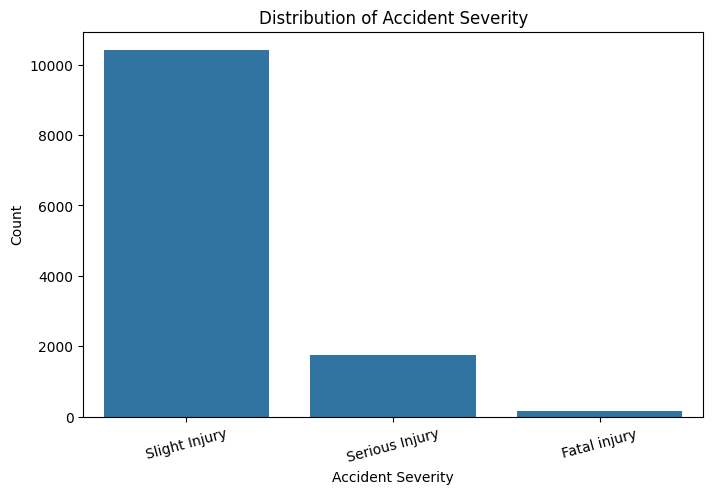

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='accident_severity', order=df_clean['accident_severity'].value_counts().index)
plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

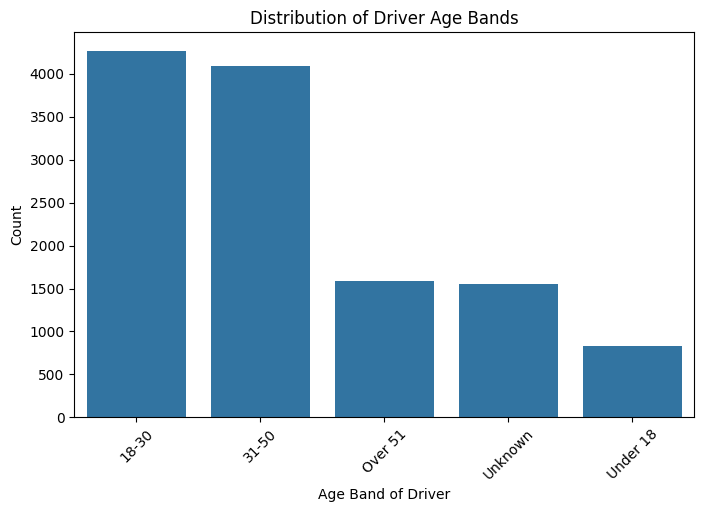

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='age_band_of_driver', order=df_clean['age_band_of_driver'].value_counts().index)
plt.title("Distribution of Driver Age Bands")
plt.xlabel("Age Band of Driver")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

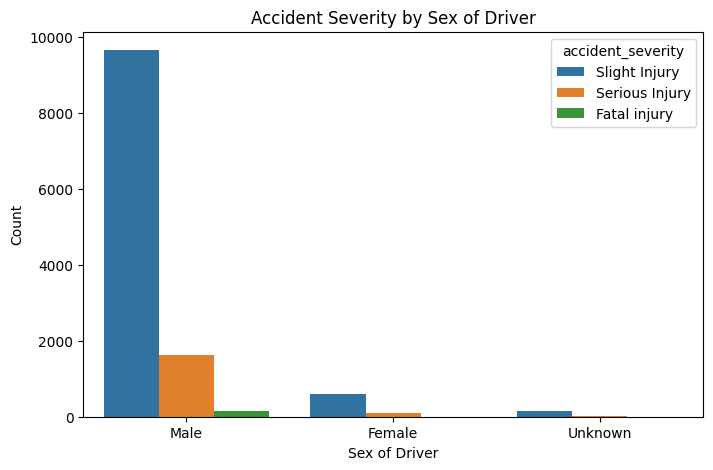

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='sex_of_driver', hue='accident_severity')
plt.title("Accident Severity by Sex of Driver")
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.show()

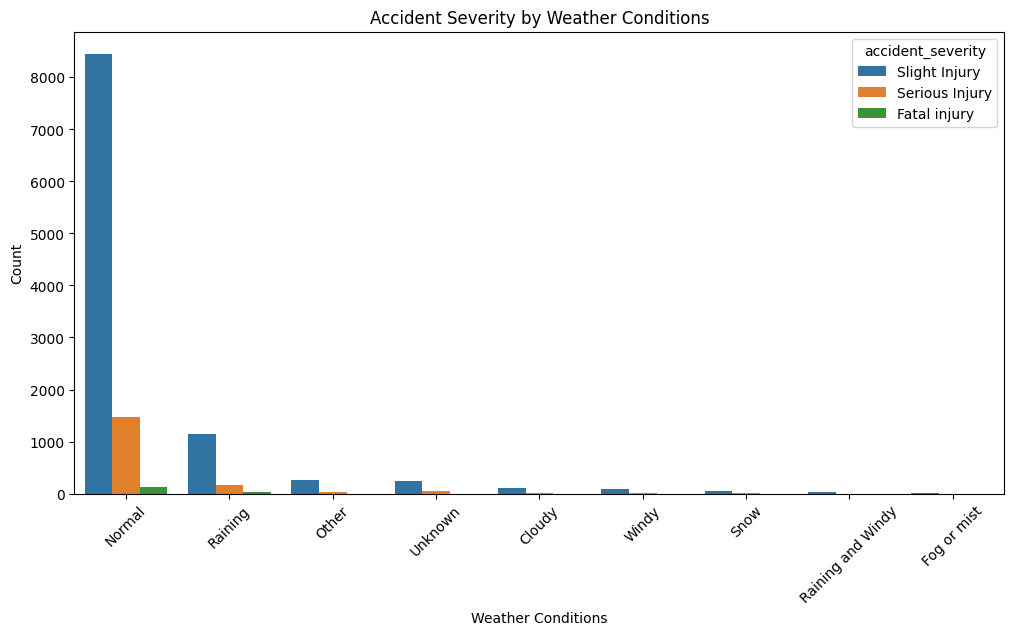

In [27]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_clean, x='weather_conditions', hue='accident_severity',
              order=df_clean['weather_conditions'].value_counts().index)
plt.title("Accident Severity by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

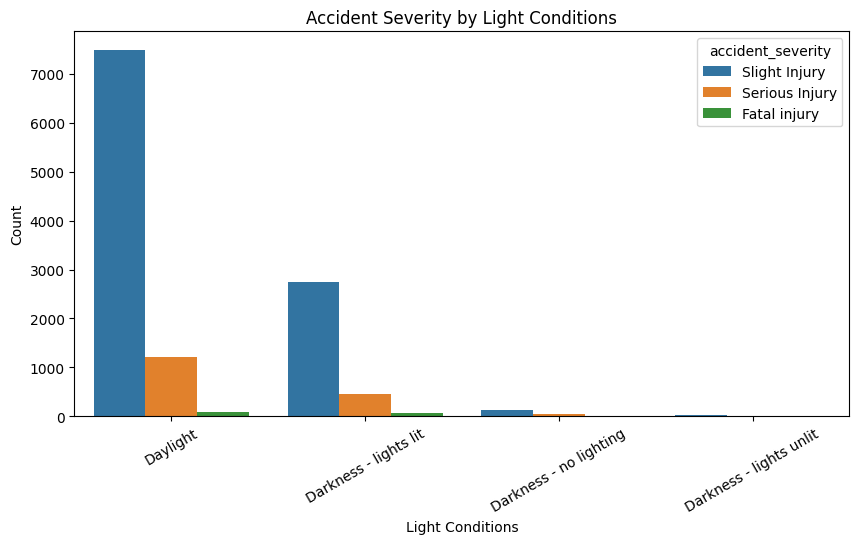

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='light_conditions', hue='accident_severity',
              order=df_clean['light_conditions'].value_counts().index)
plt.title("Accident Severity by Light Conditions")
plt.xlabel("Light Conditions")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

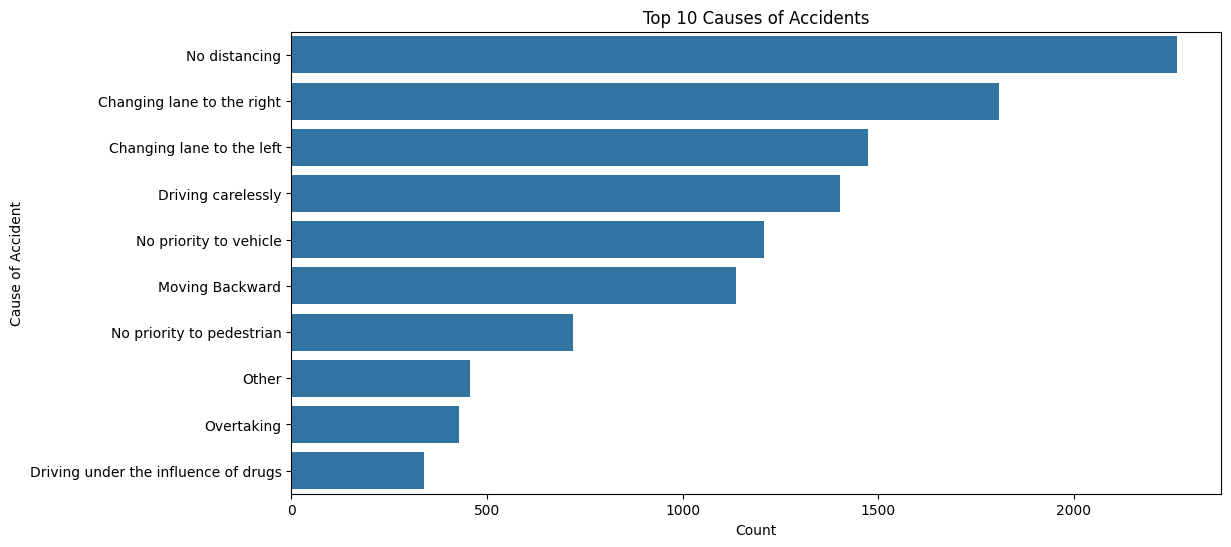

In [29]:
top_causes = df_clean['cause_of_accident'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_causes.values, y=top_causes.index)
plt.title("Top 10 Causes of Accidents")
plt.xlabel("Count")
plt.ylabel("Cause of Accident")
plt.show()

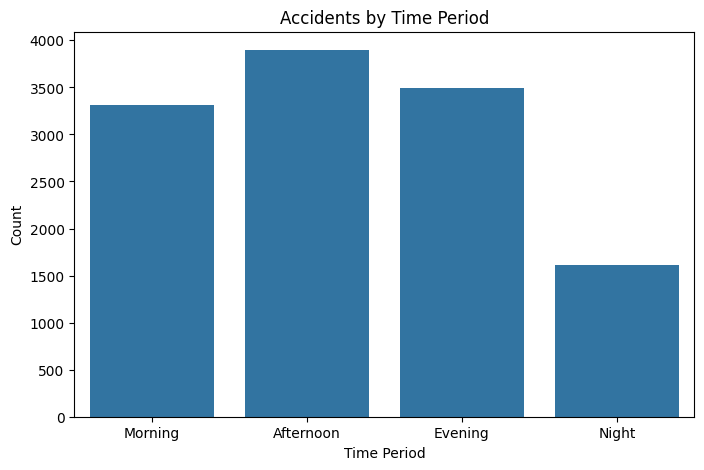

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='time_period', order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title("Accidents by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Count")
plt.show()

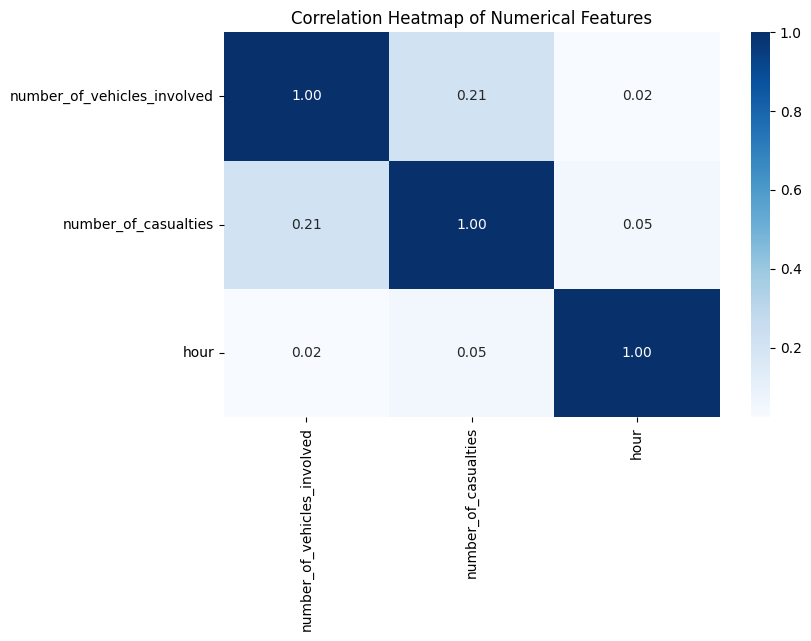

In [31]:
plt.figure(figsize=(8,5))
corr = df_clean[['number_of_vehicles_involved', 'number_of_casualties', 'hour']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Data Preprocessing + Train/Test Split + Encoding

In [32]:
X = df_clean.drop('accident_severity', axis=1)
y = df_clean['accident_severity']
#Define features (X) and target (y)

In [33]:
print("X shape:", X.shape)
print("y shape:", y.shape)
#Check X and y shape CODE


X shape: (12316, 26)
y shape: (12316,)


In [34]:
#Encode target column using LabelEncoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [35]:
#See class mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class mapping:", class_mapping)

Class mapping: {'Fatal injury': np.int64(0), 'Serious Injury': np.int64(1), 'Slight Injury': np.int64(2)}


In [36]:
#Separate categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

Categorical columns: ['day_of_week', 'age_band_of_driver', 'sex_of_driver', 'educational_level', 'vehicle_driver_relation', 'driving_experience', 'type_of_vehicle', 'owner_of_vehicle', 'service_year_of_vehicle', 'defect_of_vehicle', 'area_accident_occured', 'lanes_or_medians', 'road_allignment', 'types_of_junction', 'road_surface_type', 'road_surface_conditions', 'light_conditions', 'weather_conditions', 'type_of_collision', 'vehicle_movement', 'pedestrian_movement', 'cause_of_accident', 'time_period']

Numerical columns: ['number_of_vehicles_involved', 'number_of_casualties', 'hour']


In [37]:
#Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [38]:
#Check train/test shapes CODE
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9852, 26)
X_test shape: (2464, 26)
y_train shape: (9852,)
y_test shape: (2464,)


In [39]:
#Create preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [40]:
#Now define the transformers
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = StandardScaler()

In [41]:
#Combine preprocessing for categorical + numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numerical_transformer, numerical_cols)
    ]
)

In [42]:
#Test the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (9852, 181)
Processed X_test shape: (2464, 181)


Train Multiple Machine Learning Models and Compare Them

In [43]:
#Import ML Models and Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [44]:
#Create a Function to Train and Evaluate Models
def evaluate_model(model, model_name):
    # Create pipeline with preprocessing + model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = pipeline.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print("Accuracy:", acc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return pipeline, acc

In [45]:
#Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_pipeline, log_acc = evaluate_model(log_model, "Logistic Regression")


Logistic Regression
Accuracy: 0.8465909090909091

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.67      0.01      0.02       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.50      0.34      0.31      2464
weighted avg       0.81      0.85      0.78      2464



In [46]:
#Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_pipeline, dt_acc = evaluate_model(dt_model, "Decision Tree")


Decision Tree
Accuracy: 0.7763798701298701

Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.26      0.27        31
           1       0.28      0.29      0.28       349
           2       0.87      0.87      0.87      2084

    accuracy                           0.78      2464
   macro avg       0.47      0.47      0.47      2464
weighted avg       0.78      0.78      0.78      2464



In [47]:
#Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_pipeline, rf_acc = evaluate_model(rf_model, "Random Forest")


Random Forest
Accuracy: 0.8474025974025974

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.83      0.01      0.03       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.56      0.34      0.32      2464
weighted avg       0.83      0.85      0.78      2464



In [48]:
#TRAIN K NEAREST NEIGHBOUR
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_pipeline, knn_acc = evaluate_model(knn_model, "K-Nearest Neighbors")


K-Nearest Neighbors
Accuracy: 0.8409090909090909

Classification Report:

              precision    recall  f1-score   support

           0       0.33      0.06      0.11        31
           1       0.41      0.08      0.14       349
           2       0.86      0.98      0.91      2084

    accuracy                           0.84      2464
   macro avg       0.53      0.38      0.39      2464
weighted avg       0.79      0.84      0.79      2464



In [49]:
# Compare results
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'K-Nearest Neighbors'],
    'Accuracy': [log_acc, dt_acc, rf_acc, knn_acc]
})

model_results = model_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\nModel Comparison:")
display(model_results)



Model Comparison:


,Model,Accuracy
0,Random Forest,0.847403
1,Logistic Regression,0.846591
2,K-Nearest Neighbors,0.840909
3,Decision Tree,0.776380


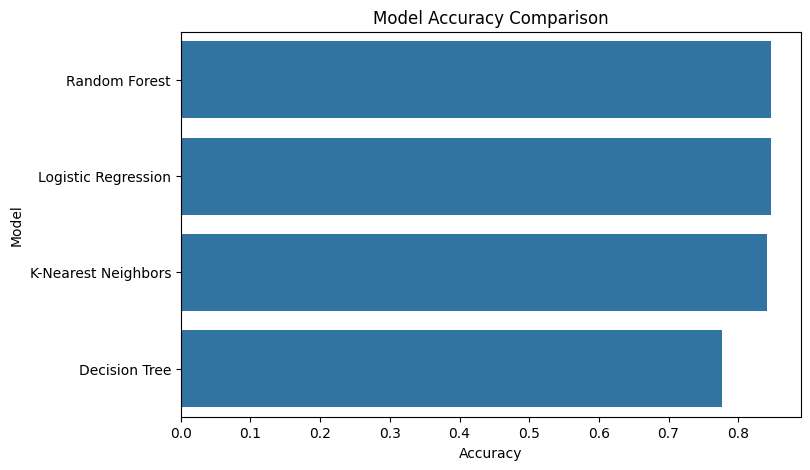

In [50]:

# Plot comparison
plt.figure(figsize=(8,5))
sns.barplot(data=model_results, x='Accuracy', y='Model')
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

Hyperparameter Tuning

In [51]:
#Import tuning library
from sklearn.model_selection import RandomizedSearchCV

In [52]:
#Tune Random Forest
from sklearn.model_selection import RandomizedSearchCV

# Random Forest pipeline
rf_pipeline_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Parameter grid
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}


In [53]:
# Randomized Search
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline_tune,
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [54]:
# Fit search
rf_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [10, 20, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [55]:
# Best model
best_rf_model = rf_random_search.best_estimator_

In [56]:
# Predict
y_pred_rf = best_rf_model.predict(X_test)

In [57]:

# Accuracy
rf_tuned_acc = accuracy_score(y_test, y_pred_rf)

print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

print("\nTuned Random Forest Accuracy:")
print(rf_tuned_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Best Random Forest Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 30}

Tuned Random Forest Accuracy:
0.8482142857142857

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.78      0.02      0.04       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.54      0.34      0.32      2464
weighted avg       0.83      0.85      0.78      2464



In [58]:
#Tune Decision Tree

In [59]:
# Decision Tree pipeline
dt_pipeline_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Parameter grid
dt_param_grid = {
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__criterion': ['gini', 'entropy']
}

In [60]:

# Randomized Search
dt_random_search = RandomizedSearchCV(
    estimator=dt_pipeline_tune,
    param_distributions=dt_param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [61]:
# Fit search
dt_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [62]:
# Best model
best_dt_model = dt_random_search.best_estimator_

In [63]:
# Predict
y_pred_dt = best_dt_model.predict(X_test)

In [64]:
# Accuracy
dt_tuned_acc = accuracy_score(y_test, y_pred_dt)

print("Best Decision Tree Parameters:")
print(dt_random_search.best_params_)

print("\nTuned Decision Tree Accuracy:")
print(dt_tuned_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Best Decision Tree Parameters:
{'model__min_samples_split': 5, 'model__min_samples_leaf': 8, 'model__max_depth': 10, 'model__criterion': 'gini'}

Tuned Decision Tree Accuracy:
0.614448051948052

Classification Report:

              precision    recall  f1-score   support

           0       0.05      0.55      0.08        31
           1       0.26      0.41      0.31       349
           2       0.88      0.65      0.75      2084

    accuracy                           0.61      2464
   macro avg       0.40      0.54      0.38      2464
weighted avg       0.78      0.61      0.68      2464



In [65]:
#Compare tuned models with original best models
tuned_results = pd.DataFrame({
    'Model': [
        'Random Forest (Original)',
        'Random Forest (Tuned)',
        'Decision Tree (Original)',
        'Decision Tree (Tuned)',
        'Logistic Regression',
        'K-Nearest Neighbors'
    ],
    'Accuracy': [
        rf_acc,
        rf_tuned_acc,
        dt_acc,
        dt_tuned_acc,
        log_acc,
        knn_acc
    ]
})

tuned_results = tuned_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Final Model Comparison:")
display(tuned_results)

Final Model Comparison:


,Model,Accuracy
0,Random Forest (Tuned),0.848214
1,Random Forest (Original),0.847403
2,Logistic Regression,0.846591
3,K-Nearest Neighbors,0.840909
4,Decision Tree (Original),0.776380
5,Decision Tree (Tuned),0.614448


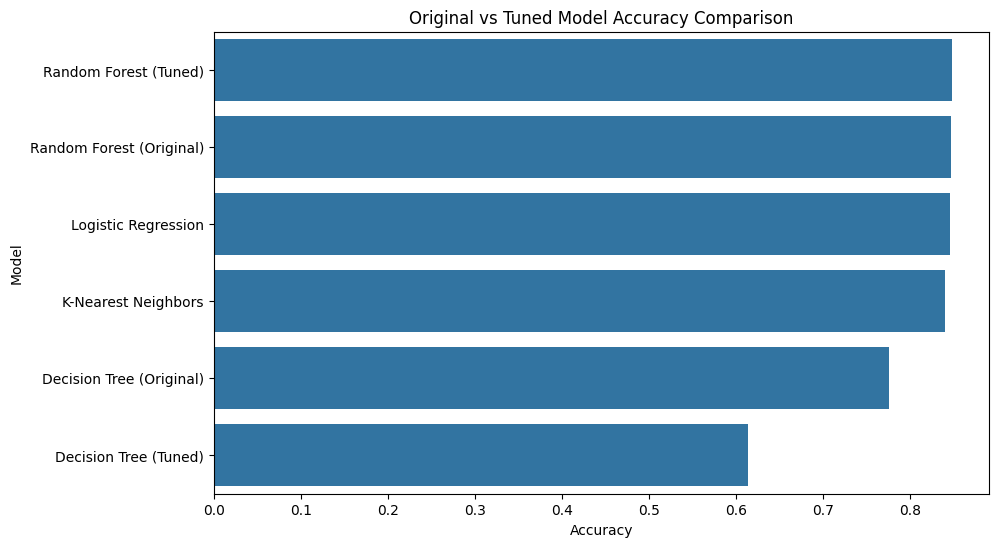

In [66]:
#Plot tuned comparison
plt.figure(figsize=(10,6))
sns.barplot(data=tuned_results, x='Accuracy', y='Model')
plt.title("Original vs Tuned Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

Save the Best Model

In [68]:
import joblib

# Save the best model
joblib.dump(best_rf_model, "best_road_accident_severity_model.pkl")

print("Best model saved successfully!")

# Load the saved model
loaded_model = joblib.load("best_road_accident_severity_model.pkl")

print("Model loaded successfully!")

# Test prediction on one sample
sample_input = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample_input)

print("Sample Prediction:", sample_prediction[0])
print("Actual Value:", y_test[0])

Best model saved successfully!
Model loaded successfully!
Sample Prediction: 2
Actual Value: 2


In [69]:
print(df_clean.columns.tolist())

['day_of_week', 'age_band_of_driver', 'sex_of_driver', 'educational_level', 'vehicle_driver_relation', 'driving_experience', 'type_of_vehicle', 'owner_of_vehicle', 'service_year_of_vehicle', 'defect_of_vehicle', 'area_accident_occured', 'lanes_or_medians', 'road_allignment', 'types_of_junction', 'road_surface_type', 'road_surface_conditions', 'light_conditions', 'weather_conditions', 'type_of_collision', 'number_of_vehicles_involved', 'number_of_casualties', 'vehicle_movement', 'pedestrian_movement', 'cause_of_accident', 'accident_severity', 'hour', 'time_period']


In [70]:
streamlit_test_input = df_clean.drop("accident_severity", axis=1)
streamlit_test_input.to_csv("streamlit_test_input.csv", index=False)

print("streamlit_test_input.csv created successfully!")

streamlit_test_input.csv created successfully!
